## ANN using pytorch

In [120]:
import pandas as pd
import numpy as np
import torch 
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [121]:
device=torch.device('cuda'if torch.cuda.is_available() else "cpu")
print(f"using device:{device}")

using device:cuda


In [122]:
#set random seed for reproducibility
torch.manual_seed(42)


In [123]:
import os
print(os.getcwd())  # shows current working directory


d:\coding\LEARNING\pytorch\ANN


In [124]:
df=pd.read_csv("archive/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


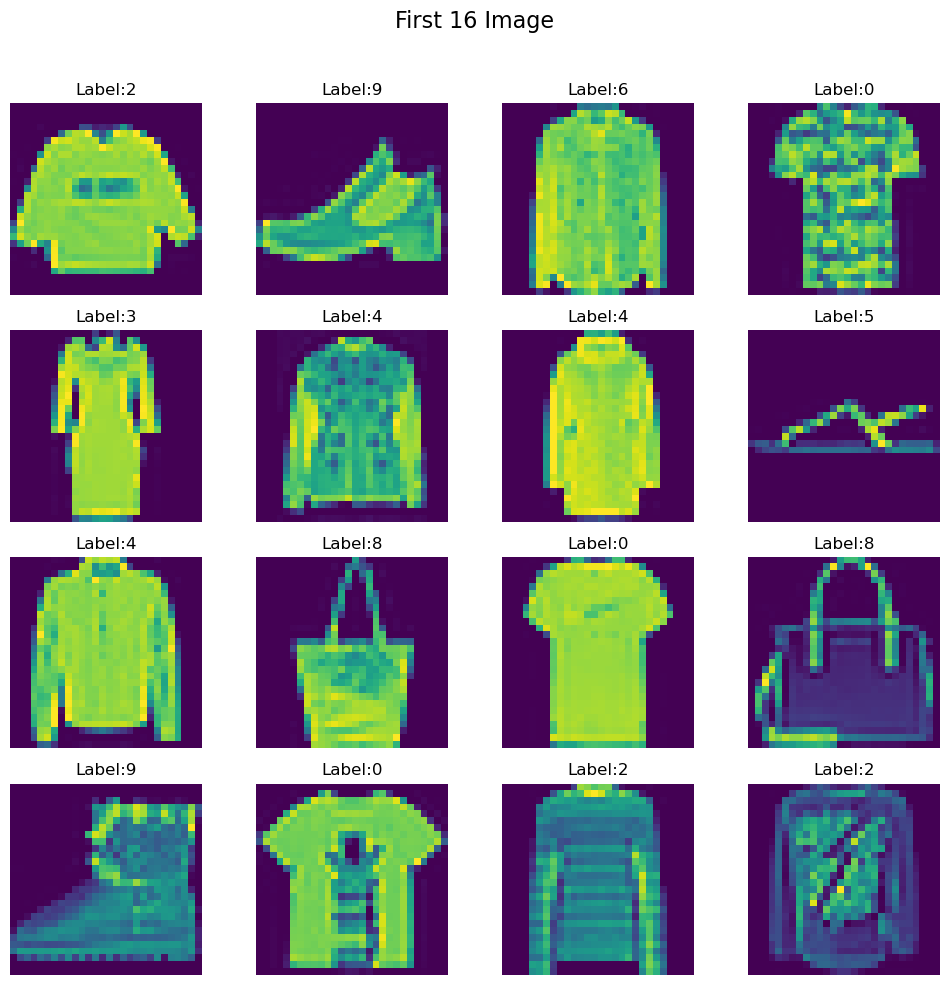

In [125]:
#create a 4*4 grid
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Image",fontsize=16)

#plot the first 16 images from the dataset
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28) #rehsape to 28*28
    ax.imshow(img)#dislay in greyscale
    ax.axis('off')#remoce axis for a cleaner look
    ax.set_title(f"Label:{df.iloc[i,0]}")#show the label
    
plt.tight_layout(rect=[0,0,1,0.96])#adjust layout to fit the title
plt.show()

In [126]:
#train test split
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [127]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784))

In [128]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [129]:
#scaling the features  
x_train=x_train/255.0
x_test=x_test/255.0



In [130]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]], shape=(48000, 784))

In [131]:
#create custom DatasetClass
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self,index):
        return self.features[index],self.labels[index]
        

In [132]:
#creaset train_dataset_opbject
train_dataset=CustomDataset(x_train,y_train)


In [133]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

In [134]:
#create test_dataset_object
test_dataset=CustomDataset(x_test,y_test)

In [135]:
#create traina ndt test loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True) #shuffling can cause error on finging valuye ont est

In [136]:
#define NN Neural Network class
class MYNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
            # no need to explitcly ass nn.Softmax as in pytorch by default it add 
            # for CROSS ENTROPOLY LOSS for this ..just by defualt to be exact 
        )
    def forward(self,x):
        return self.model(x)
    
    
    

In [137]:
#set Learning rate and epoch
epochs=100
learning_rate=0.1

In [138]:
x_train.shape[1]

784

In [139]:
#instatiate the model
model=MYNN(x_train.shape[1])
model.to(device)

#loss functon
criterion=nn.CrossEntropyLoss()
#optimizer
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [140]:
#trainning loop
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_loader:
        #move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        #forward pass
        outputs=model(batch_features)
        #calcuate loss
        loss=criterion(outputs,batch_labels)
        #back pass
        optimizer.zero_grad()
        loss.backward()
        #graident update
        optimizer.step()
        
        total_epoch_loss=total_epoch_loss+loss.item()
    avg_loss=total_epoch_loss/len(train_loader)
    print(f"epoch:{epoch+1}, AVG LOSS :{avg_loss}")
    

epoch:1, AVG LOSS :0.635193983823061
epoch:2, AVG LOSS :0.42952238681415716
epoch:3, AVG LOSS :0.3869724465931455
epoch:4, AVG LOSS :0.3589792065322399
epoch:5, AVG LOSS :0.337393187319239
epoch:6, AVG LOSS :0.32317901170005403
epoch:7, AVG LOSS :0.3076348851894339
epoch:8, AVG LOSS :0.29553309770176805
epoch:9, AVG LOSS :0.285360195821772
epoch:10, AVG LOSS :0.27353458426023525
epoch:11, AVG LOSS :0.26828947985668977
epoch:12, AVG LOSS :0.25840319122746586
epoch:13, AVG LOSS :0.2504708759797116
epoch:14, AVG LOSS :0.24585035655026635
epoch:15, AVG LOSS :0.24032416047155858
epoch:16, AVG LOSS :0.23308741933231553
epoch:17, AVG LOSS :0.22659470405305426
epoch:18, AVG LOSS :0.22024774242813389
epoch:19, AVG LOSS :0.21402468410755196
epoch:20, AVG LOSS :0.20909977698108803
epoch:21, AVG LOSS :0.2063814871435364
epoch:22, AVG LOSS :0.20201907060233254
epoch:23, AVG LOSS :0.1961098784810553
epoch:24, AVG LOSS :0.19319878923210004
epoch:25, AVG LOSS :0.18844192198850215
epoch:26, AVG LOSS :0

In [141]:
#set model to eval mode
model.eval()

MYNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [142]:
#evaluation code by manually

total=0
correct=0
with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        #move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        outputs=model(batch_features)
        
        _, predicted=torch.max(outputs,1)
        total=total+ batch_labels.shape[0]
        correct=correct +(predicted ==batch_labels).sum().item()
        
print(correct/total)


0.883


In [143]:
len(test_loader)


375